# N-Grams Language Model

N-grams are contiguous sequences of n items from a given sequence of text. This notebook implements n-gram language models.

## Types of N-grams:
1. Unigrams (n=1)
2. Bigrams (n=2)
3. Trigrams (n=3)

In [ ]:
import nltk
from nltk import ngrams
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Download required NLTK data
nltk.download('gutenberg')

from nltk.corpus import gutenberg

# Sample text
text = """The quick brown fox jumps over the lazy dog. 
The fox is quick and brown. The dog is lazy."""

# Tokenize the text
tokens = nltk.word_tokenize(text.lower())

# Generate n-grams
unigrams = list(ngrams(tokens, 1))
bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

print("Unigrams:", unigrams[:5])
print("\nBigrams:", bigrams[:5])
print("\nTrigrams:", trigrams[:5])

Unigrams: [('the',), ('quick',), ('brown',), ('fox',), ('jumps',)]

Bigrams: [('the', 'quick'), ('quick', 'brown'), ('brown', 'fox'), ('fox', 'jumps'), ('jumps', 'over')]

Trigrams: [('the', 'quick', 'brown'), ('quick', 'brown', 'fox'), ('brown', 'fox', 'jumps'), ('fox', 'jumps', 'over'), ('jumps', 'over', 'the')]


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package gutenberg to /usr/share/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [11]:
# Calculate probabilities
def calculate_ngram_probability(ngrams_list):
    ngram_counts = Counter(ngrams_list)
    total_ngrams = len(ngrams_list)
    
    probabilities = {}
    for ngram in ngram_counts:
        probabilities[ngram] = ngram_counts[ngram] / total_ngrams
    
    return probabilities

# Get probabilities for bigrams
bigram_probs = calculate_ngram_probability(bigrams)

# Print some probabilities
print("\nBigram Probabilities:")
for bigram, prob in list(bigram_probs.items())[:5]:
    print(f"{bigram}: {prob:.4f}")


Bigram Probabilities:
('the', 'quick'): 0.0476
('quick', 'brown'): 0.0476
('brown', 'fox'): 0.0476
('fox', 'jumps'): 0.0476
('jumps', 'over'): 0.0476


In [12]:
# Let's use a Shakespeare text for better analysis
shakespeare_text = gutenberg.raw('shakespeare-hamlet.txt')

# Tokenize the text
tokens = nltk.word_tokenize(shakespeare_text.lower())

# Generate n-grams
unigrams = list(ngrams(tokens, 1))
bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

# Count frequencies
unigram_freq = Counter(unigrams)
bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

# Display most common n-grams
print("Most common unigrams:")
for item, count in unigram_freq.most_common(10):
    print(f"{item}: {count}")

print("\nMost common bigrams:")
for item, count in bigram_freq.most_common(10):
    print(f"{item}: {count}")

print("\nMost common trigrams:")
for item, count in trigram_freq.most_common(10):
    print(f"{item}: {count}")

Most common unigrams:
(',',): 2892
('.',): 1877
('the',): 993
('and',): 862
('to',): 683
('of',): 610
(':',): 566
('i',): 560
('you',): 527
('my',): 502

Most common bigrams:
(',', 'and'): 465
('ham', '.'): 337
('my', 'lord'): 175
('.', 'i'): 151
(',', 'that'): 136
(',', 'i'): 102
('king', '.'): 96
('hor', '.'): 95
(',', 'the'): 93
(',', 'to'): 79

Most common trigrams:
('my', 'lord', ','): 63
('?', 'ham', '.'): 62
('lord', 'ham', '.'): 44
(',', 'my', 'lord'): 43
('ham', '.', 'i'): 42
('my', 'lord', 'ham'): 41
('?', 'hor', '.'): 30
('.', 'my', 'lord'): 28
('my', 'lord', '?'): 28
('lord', '?', 'ham'): 23


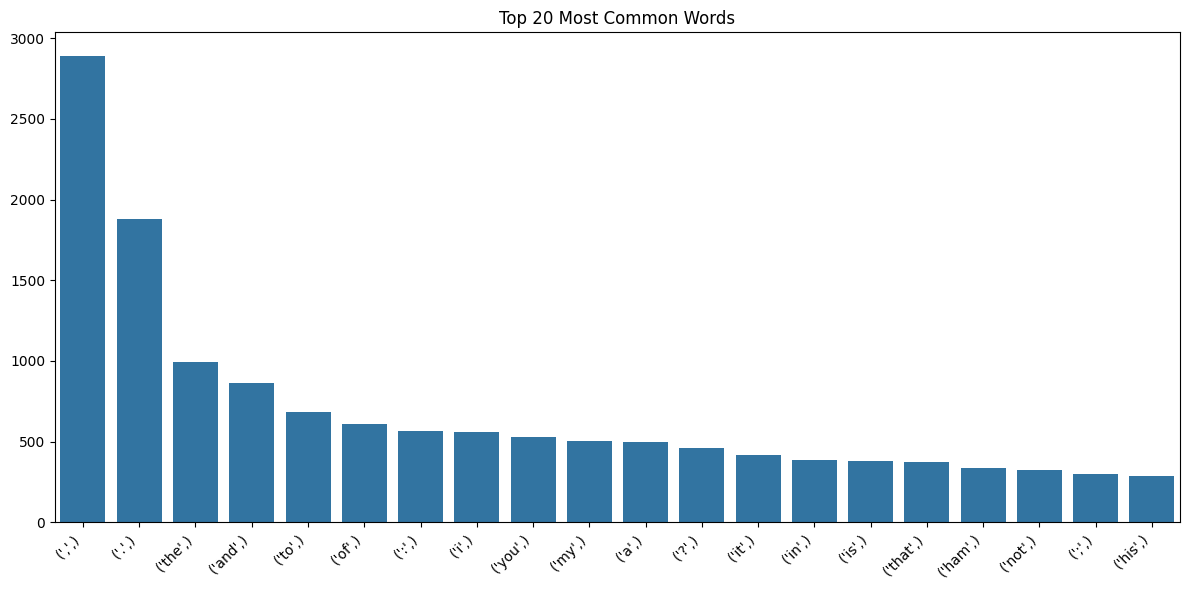

In [13]:
# Visualize top unigrams
plt.figure(figsize=(12, 6))
top_unigrams = dict(unigram_freq.most_common(20))
sns.barplot(x=list(map(str, top_unigrams.keys())), y=list(top_unigrams.values()))
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Common Words')
plt.tight_layout()
plt.show()

In [14]:
# Calculate conditional probabilities for bigrams
def calculate_bigram_probability(word1, word2, bigram_counts, unigram_counts):
    bigram = (word1, word2)
    if bigram in bigram_counts:
        return bigram_counts[bigram] / unigram_counts[(word1,)]
    return 0

# Example: Calculate probability of some common word sequences
test_sequences = [
    ('to', 'be'),
    ('be', 'or'),
    ('or', 'not'),
    ('not', 'to')
]

print("\nBigram Probabilities:")
for word1, word2 in test_sequences:
    prob = calculate_bigram_probability(word1, word2, bigram_freq, unigram_freq)
    print(f"P({word2}|{word1}) = {prob:.4f}")


Bigram Probabilities:
P(be|to) = 0.0425
P(or|be) = 0.0000
P(not|or) = 0.0291
P(to|not) = 0.0367


In [15]:
# Simple text generation using bigrams
def generate_text(seed_word, bigram_counts, length=10):
    current_word = seed_word
    text = [seed_word]
    
    for _ in range(length):
        # Find all possible next words
        possible_words = [(pair[1], count) for pair, count in bigram_counts.items() 
                         if pair[0] == current_word]
        
        if not possible_words:
            break
            
        # Choose next word based on frequency
        total = sum(count for word, count in possible_words)
        probabilities = [count/total for word, count in possible_words]
        next_word = np.random.choice([word for word, _ in possible_words], p=probabilities)
        
        text.append(next_word)
        current_word = next_word
    
    return ' '.join(text)

# Generate some sample texts
print("\nGenerated text samples:")
for seed in ['the', 'to', 'and']:
    print(f"\nStarting with '{seed}':")
    print(generate_text(seed, bigram_freq))


Generated text samples:

Starting with 'the':
the hilts , lord , and the men , most select

Starting with 'to':
to post with her owne ennactors with remembrance of my aduice

Starting with 'and':
and could finde it is thine , nor plautus too narrow
